# Olist E-Commerce SQL Analysis

## Overview
SQL analysis of 100,000+ Brazilian e-commerce orders using SQLite.
Multiple tables joined to extract business insights.

## Key Findings
- São Paulo (SP) dominates with 41,746 orders (42% of total)
- Health & Beauty is the highest revenue category ($1.26M)
- SP has the fastest delivery at 8.8 days average
- 57.8% of customers gave 5-star reviews
- bed_bath_table is the most sold category (11,115 items)
- Top sellers are concentrated in SP state


In [1]:
# Gerekli kütüphaneleri yükle
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# SQLite veritabanı oluştur
conn = sqlite3.connect('olist.db')

print("Database created successfully!")

Database created successfully!


In [2]:
# Dosyaları yükle
from google.colab import files
uploaded = files.upload()

Saving olist_customers_dataset.csv to olist_customers_dataset.csv
Saving olist_geolocation_dataset.csv to olist_geolocation_dataset.csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset.csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv
Saving olist_products_dataset.csv to olist_products_dataset.csv
Saving olist_sellers_dataset.csv to olist_sellers_dataset.csv
Saving product_category_name_translation.csv to product_category_name_translation.csv


In [3]:
# CSV dosyalarını veritabanına aktar
tables = {
    'customers': 'olist_customers_dataset.csv',
    'orders': 'olist_orders_dataset.csv',
    'order_items': 'olist_order_items_dataset.csv',
    'order_payments': 'olist_order_payments_dataset.csv',
    'order_reviews': 'olist_order_reviews_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'sellers': 'olist_sellers_dataset.csv',
    'geolocation': 'olist_geolocation_dataset.csv',
    'category_translation': 'product_category_name_translation.csv'
}

for table_name, file_name in tables.items():
    df = pd.read_csv(file_name)
    df.to_sql(table_name, conn, if_exists='replace', index=False)
    print(f"✅ {table_name} loaded — {len(df)} rows")

✅ customers loaded — 99441 rows
✅ orders loaded — 99441 rows
✅ order_items loaded — 112650 rows
✅ order_payments loaded — 103886 rows
✅ order_reviews loaded — 99224 rows
✅ products loaded — 32951 rows
✅ sellers loaded — 3095 rows
✅ geolocation loaded — 1000163 rows
✅ category_translation loaded — 71 rows


In [4]:
# SQL sorgusu çalıştırmak için fonksiyon
def run_query(query):
    return pd.read_sql_query(query, conn)

# Soru 1: En çok sipariş veren eyaletler hangileri?
q1 = """
SELECT
    c.customer_state,
    COUNT(o.order_id) as total_orders
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_state
ORDER BY total_orders DESC
LIMIT 10;
"""

result1 = run_query(q1)
print(result1)

  customer_state  total_orders
0             SP         41746
1             RJ         12852
2             MG         11635
3             RS          5466
4             PR          5045
5             SC          3637
6             BA          3380
7             DF          2140
8             ES          2033
9             GO          2020


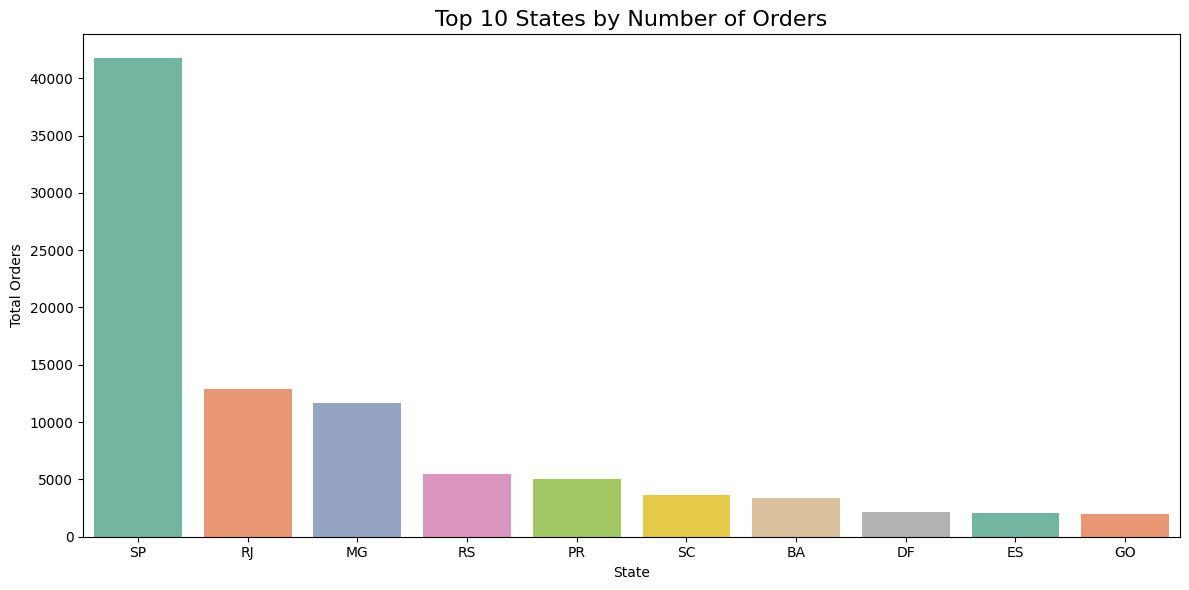

In [5]:
# Görselleştirme
plt.figure(figsize=(12, 6))
sns.barplot(data=result1, x='customer_state', y='total_orders',
            hue='customer_state', palette='Set2', legend=False)
plt.title('Top 10 States by Number of Orders', fontsize=16)
plt.xlabel('State')
plt.ylabel('Total Orders')
plt.tight_layout()
plt.show()

In [6]:
q2 = """
SELECT
    t.product_category_name_english as category,
    ROUND(SUM(oi.price), 2) as total_revenue
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
JOIN category_translation t ON p.product_category_name = t.product_category_name
GROUP BY category
ORDER BY total_revenue DESC
LIMIT 10;
"""

result2 = run_query(q2)
print(result2)

                category  total_revenue
0          health_beauty     1258681.34
1          watches_gifts     1205005.68
2         bed_bath_table     1036988.68
3         sports_leisure      988048.97
4  computers_accessories      911954.32
5        furniture_decor      729762.49
6             cool_stuff      635290.85
7             housewares      632248.66
8                   auto      592720.11
9           garden_tools      485256.46


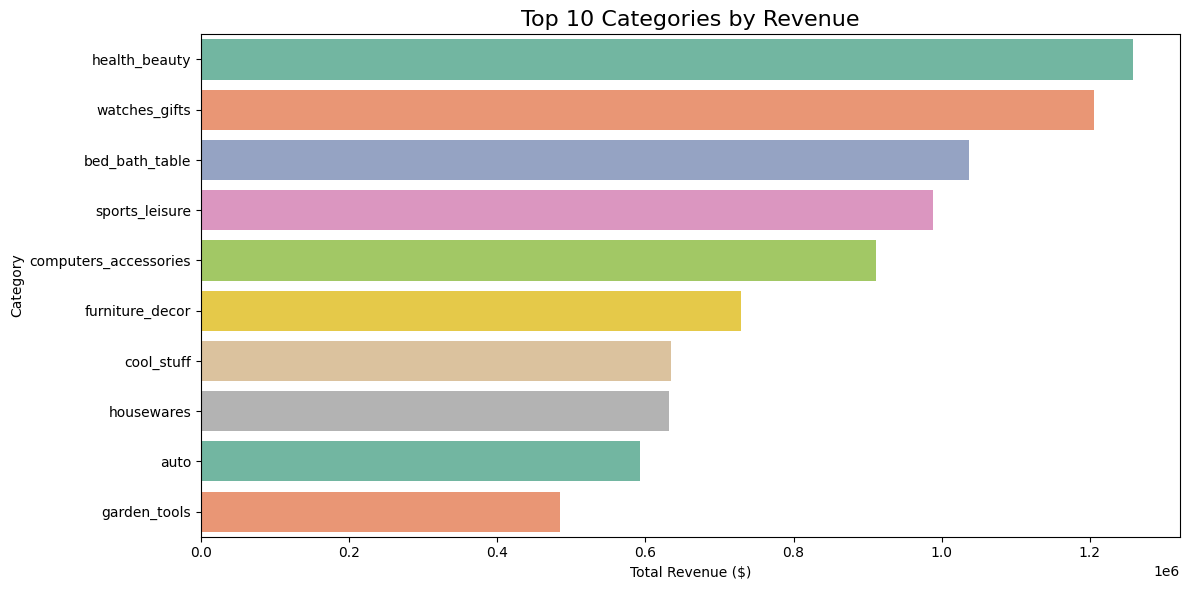

In [7]:
# Soru 2 Görselleştirme
plt.figure(figsize=(12, 6))
sns.barplot(data=result2, x='total_revenue', y='category',
            hue='category', palette='Set2', legend=False)
plt.title('Top 10 Categories by Revenue', fontsize=16)
plt.xlabel('Total Revenue ($)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [8]:
q3 = """
SELECT
    c.customer_state,
    ROUND(AVG(
        JULIANDAY(o.order_delivered_customer_date) -
        JULIANDAY(o.order_purchase_timestamp)
    ), 1) as avg_delivery_days
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_state
ORDER BY avg_delivery_days ASC
LIMIT 10;
"""

result3 = run_query(q3)
print(result3)

  customer_state  avg_delivery_days
0             SP                8.8
1             MG               12.0
2             PR               12.0
3             DF               13.0
4             SC               15.0
5             RJ               15.3
6             RS               15.3
7             GO               15.6
8             MS               15.6
9             ES               15.8


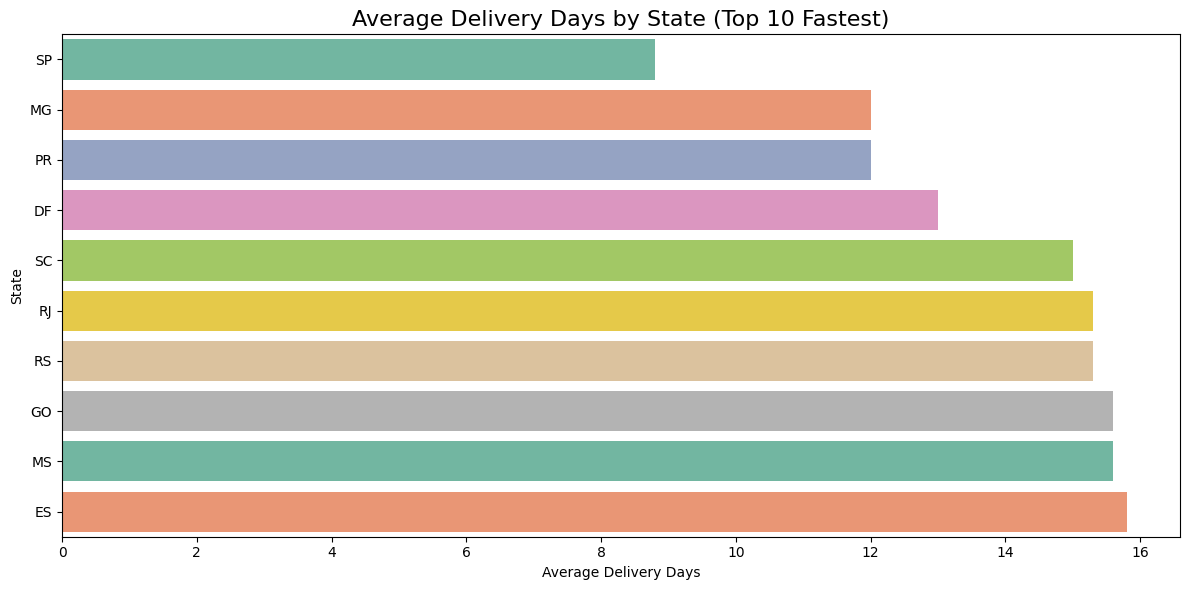

In [9]:
# Soru 3 Görselleştirme
plt.figure(figsize=(12, 6))
sns.barplot(data=result3, x='avg_delivery_days', y='customer_state',
            hue='customer_state', palette='Set2', legend=False)
plt.title('Average Delivery Days by State (Top 10 Fastest)', fontsize=16)
plt.xlabel('Average Delivery Days')
plt.ylabel('State')
plt.tight_layout()
plt.show()

In [10]:
q4 = """
SELECT
    review_score,
    COUNT(*) as total_reviews,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM order_reviews), 1) as percentage
FROM order_reviews
GROUP BY review_score
ORDER BY review_score DESC;
"""

result4 = run_query(q4)
print(result4)

   review_score  total_reviews  percentage
0             5          57328        57.8
1             4          19142        19.3
2             3           8179         8.2
3             2           3151         3.2
4             1          11424        11.5


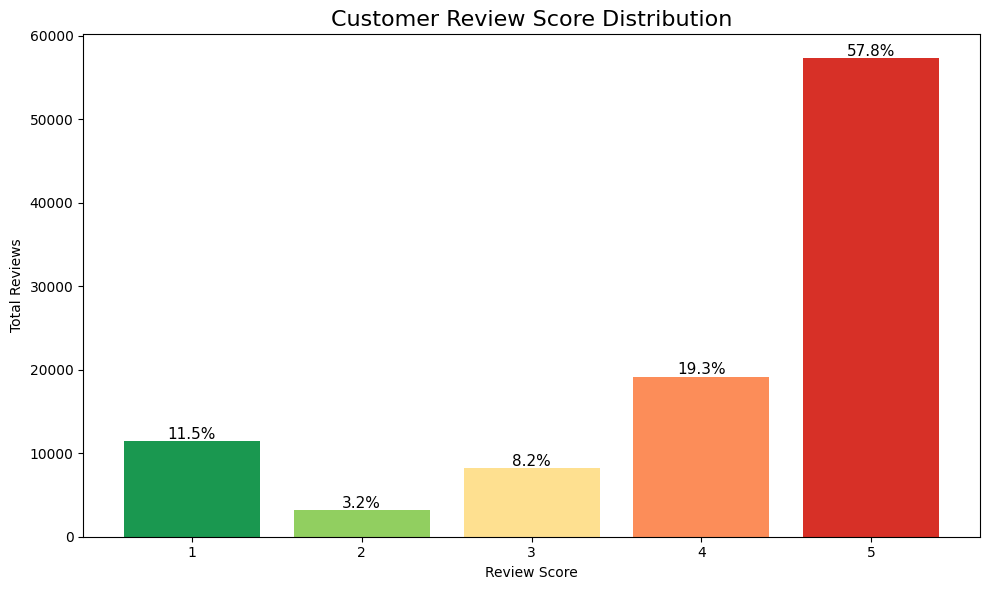

In [11]:
# Soru 4 Görselleştirme
plt.figure(figsize=(10, 6))
colors = ['#d73027', '#fc8d59', '#fee090', '#91cf60', '#1a9850']
plt.bar(result4['review_score'], result4['total_reviews'], color=colors)
plt.title('Customer Review Score Distribution', fontsize=16)
plt.xlabel('Review Score')
plt.ylabel('Total Reviews')
for i, row in result4.iterrows():
    plt.text(row['review_score'], row['total_reviews'] + 300,
             f"{row['percentage']}%", ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [12]:
q5 = """
SELECT
    t.product_category_name_english as category,
    COUNT(oi.order_id) as total_items_sold
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
JOIN category_translation t ON p.product_category_name = t.product_category_name
GROUP BY category
ORDER BY total_items_sold DESC
LIMIT 10;
"""

result5 = run_query(q5)
print(result5)

                category  total_items_sold
0         bed_bath_table             11115
1          health_beauty              9670
2         sports_leisure              8641
3        furniture_decor              8334
4  computers_accessories              7827
5             housewares              6964
6          watches_gifts              5991
7              telephony              4545
8           garden_tools              4347
9                   auto              4235


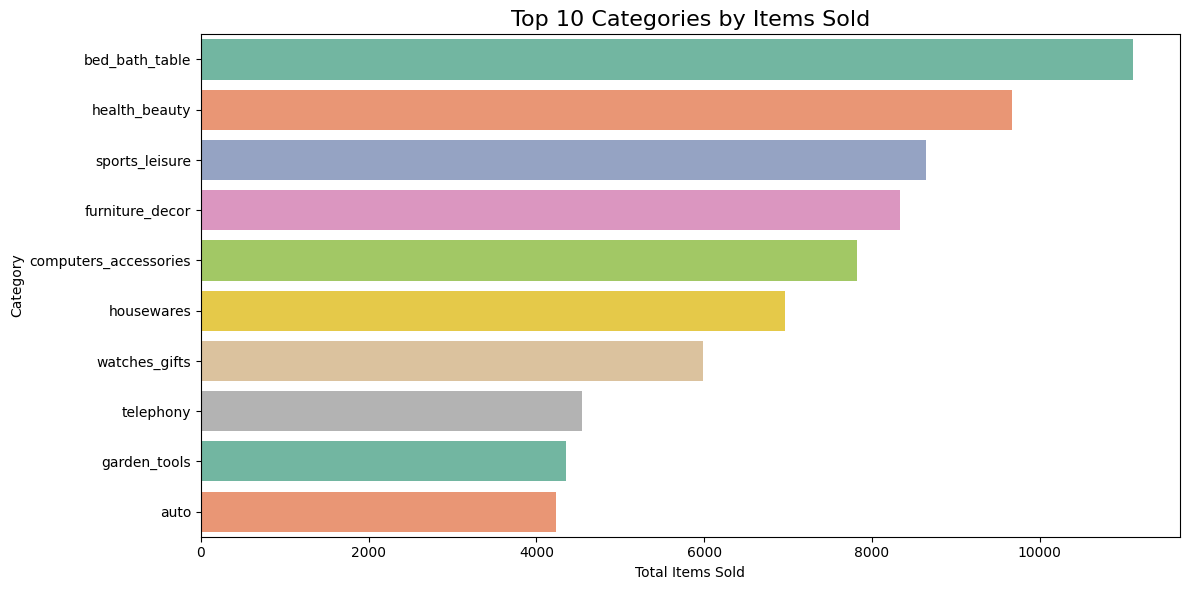

In [13]:
# Soru 5 Görselleştirme
plt.figure(figsize=(12, 6))
sns.barplot(data=result5, x='total_items_sold', y='category',
            hue='category', palette='Set2', legend=False)
plt.title('Top 10 Categories by Items Sold', fontsize=16)
plt.xlabel('Total Items Sold')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [14]:
q6 = """
SELECT
    oi.seller_id,
    s.seller_state,
    ROUND(SUM(oi.price), 2) as total_revenue,
    COUNT(oi.order_id) as total_orders
FROM order_items oi
JOIN sellers s ON oi.seller_id = s.seller_id
GROUP BY oi.seller_id, s.seller_state
ORDER BY total_revenue DESC
LIMIT 10;
"""

result6 = run_query(q6)
print(result6)

                          seller_id seller_state  total_revenue  total_orders
0  4869f7a5dfa277a7dca6462dcf3b52b2           SP      229472.63          1156
1  53243585a1d6dc2643021fd1853d8905           BA      222776.05           410
2  4a3ca9315b744ce9f8e9374361493884           SP      200472.92          1987
3  fa1c13f2614d7b5c4749cbc52fecda94           SP      194042.03           586
4  7c67e1448b00f6e969d365cea6b010ab           SP      187923.89          1364
5  7e93a43ef30c4f03f38b393420bc753a           SP      176431.87           340
6  da8622b14eb17ae2831f4ac5b9dab84a           SP      160236.57          1551
7  7a67c85e85bb2ce8582c35f2203ad736           SP      141745.53          1171
8  1025f0e2d44d7041d6cf58b6550e0bfa           SP      138968.55          1428
9  955fee9216a65b617aa5c0531780ce60           SP      135171.70          1499
